In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np

In [2]:
#-----------------------------------------------------------------------------#
#    IMAGE PREPROCESSING                                                      #
#-----------------------------------------------------------------------------#
## DIRECTORIES with datasets
img_path = 'dataset'

# Dataset with Transformation (using only 100 images)
full_dataset = datasets.ImageFolder(
    img_path,
    transforms.Compose([
        transforms.Resize((128, 256)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.0, 0.0, 0.0], 
            std=[1.0, 1.0, 1.0])
    ])
)
dataset = torch.utils.data.Subset(full_dataset, list(range(1000)))

print(f"Dataset size: {len(dataset)}")

Dataset size: 1000


In [3]:
#-----------------------------------------------------------------------------#
#    DATA LOADER                                                              #
#-----------------------------------------------------------------------------#
dataloader = DataLoader(dataset , batch_size=1, shuffle=False, num_workers=1)

# print(dataset)
# print(dataloader)
print("Min/Max:", dataset[0][0].min(), dataset[0][0].max())

Min/Max: tensor(0.) tensor(1.)


In [4]:
from pynq import get_rails, DataRecorder

rails = get_rails()
recorder = DataRecorder(rails['INT'].power)

In [5]:
recorder.record(0.01)

# Test CPU

In [6]:
class vaemodel1(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.mu = nn.Linear(256, 6)  # Reduced latent space size
        self.std = nn.Linear(256, 6)  # Reduced latent space size

    def forward(self, x):
        a = self.encoder(x).permute(0,2,3,1)
        a = torch.flatten(a, start_dim=1)
        mu = self.mu(a)
        lvar = self.std(a)
        out = torch.cat((mu, lvar), dim=1)
        return out

model = vaemodel1()

In [7]:
model.load_state_dict(torch.load("pre_trained_w_encoder.pt", weights_only=True))

<All keys matched successfully>

In [8]:
model.eval()
with torch.no_grad():
    inference_time = 0
    cpu_z = []
    recorder.mark()
    for image, _ in dataloader:
        pred = model(image)
    recorder.mark()

# Test DPU

In [9]:
from pynq_dpu import DpuOverlay
overlay = DpuOverlay("../vitisai_bitstream/dpu.bit")

In [10]:
overlay.load_model("zcu104_vaemodel1.xmodel")

In [11]:
dpu = overlay.runner

inputTensors = dpu.get_input_tensors()
outputTensors = dpu.get_output_tensors()

shapeIn = tuple(inputTensors[0].dims)
shapeOut = tuple(outputTensors[0].dims)
outputSize = int(outputTensors[0].get_data_size() / shapeIn[0])

output_data = [np.empty(shapeOut, dtype=np.float32, order="C")]
input_data = [np.empty(shapeIn, dtype=np.float32, order="C")]
data = input_data[0]

In [12]:
inference_time = 0
vitisAI_z = []
recorder.mark()
for image, _ in dataloader:
    data = image.permute(0,2,3,1)
    job_id = dpu.execute_async(input_data, output_data)
    dpu.wait(job_id)
recorder.mark()

4

In [13]:
recorder.stop()

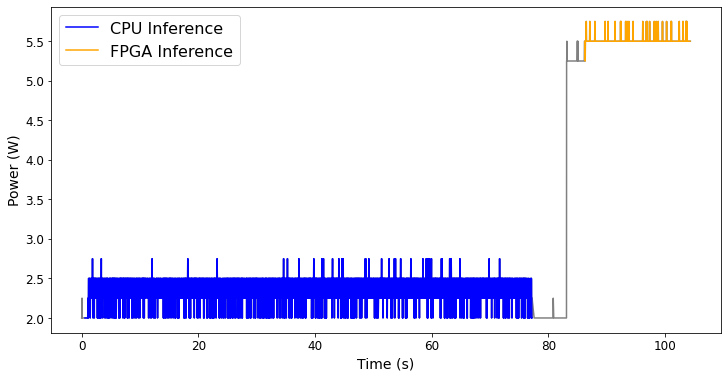

In [ ]:
import matplotlib.pyplot as plt

# Get the timestamps of the marks
mark_indices = []
last_mark = 0.0
for i, mark in enumerate(recorder.frame['Mark']):
    if mark > last_mark:
        mark_indices.append(i)
        last_mark = mark

# Extract the power data
power_data = recorder.frame['INT_power']
time_data = recorder.frame.index
elapsed_time = (time_data - time_data[0]).total_seconds()


# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(elapsed_time, power_data, color='gray')

# Color the plot based on the marks
plt.plot(elapsed_time[mark_indices[0]:mark_indices[1]], power_data[mark_indices[0]:mark_indices[1]], color='blue', label='CPU Inference')
plt.plot(elapsed_time[mark_indices[2]:mark_indices[3]], power_data[mark_indices[2]:mark_indices[3]], color='orange', label='FPGA Inference')

# Add labels and title with larger font size
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Power (W)', fontsize=14)
#plt.title('Power Consumption of CPU and FPGA Inference for MMS Neural Networks', fontsize=12)

# Add legend with larger font size
plt.legend(fontsize=16)

# Increase tick label font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.savefig("power_consumption.pdf")
plt.show()

In [15]:
max_power = max(power_data[mark_indices[0]:mark_indices[1]])
print(f"CPU maximum power consumption during execution: {max_power} W")
max_power = max(power_data[mark_indices[2]:mark_indices[3]])
print(f"FPGA maximum power consumption during execution: {max_power} W")

CPU maximum power consumption during execution: 2.75 W
FPGA maximum power consumption during execution: 5.75 W


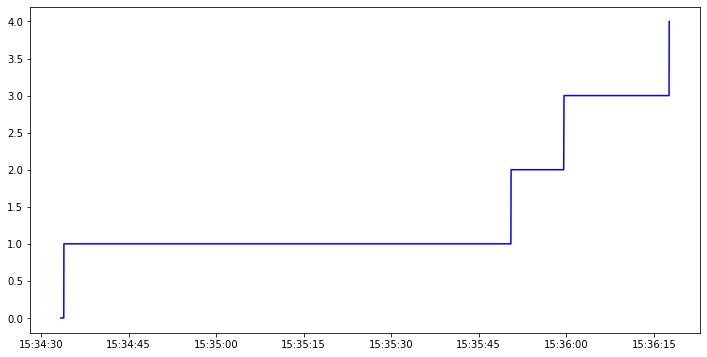

In [16]:
# Extract the power data
mark_data = recorder.frame['Mark']
time_data = recorder.frame.index

# Create the plot
plt.figure(figsize=(12, 6))

# Color the plot based on the marks
plt.plot(time_data, mark_data, color='blue', label='CPU Inference')

# Show the plot
plt.show()